<a href="https://colab.research.google.com/github/ajmalbiju56/ML/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


In [ ]:
pd.options.mode.copy_on_write = True

#data preprocessing

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Titanic-Dataset.csv")
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [ ]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
Age_mean = np.mean(df['Age'])

In [ ]:
df['Age']=df['Age'].fillna(Age_mean)

In [ ]:
Age_mean=np.mean(df['Age'])
Age_mean



np.float64(29.69911764705882)

In [ ]:
cabin_mode=df['Cabin'].mode()[0]
cabin_mode

'B96 B98'

In [ ]:
df['Cabin'] = df['Cabin'].fillna('Cabin_mode')

In [ ]:
Embarked_mode=df['Embarked'].mode()[0]
Embarked_mode

'S'

In [ ]:
df['Embarked'] = df['Embarked'].fillna('Embarked_mode')

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


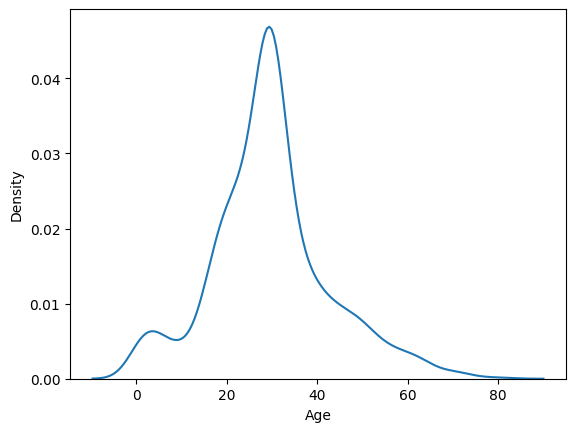

In [ ]:
sns.kdeplot(df['Age'])
plt.show()

#univariate analysis

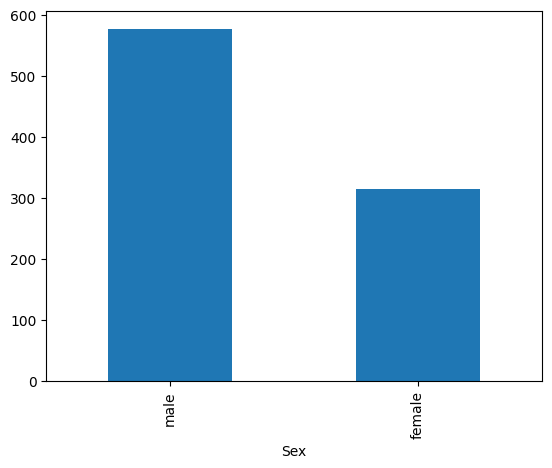

In [ ]:
df['Sex'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
#univariate
df['Sex'].nunique()

2

In [ ]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [ ]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


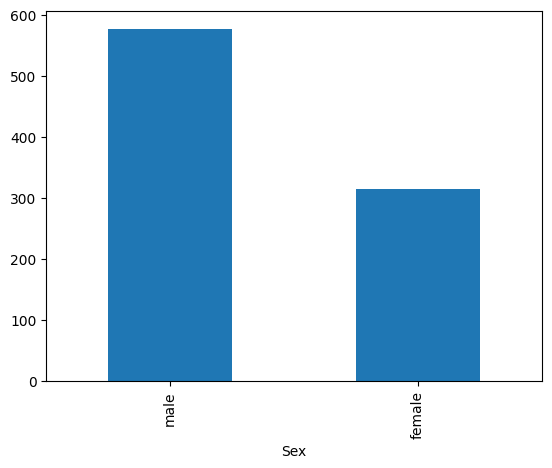

In [ ]:
df['Sex'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
num= df.select_dtypes(include=np.number)
num.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [ ]:
cat = df.select_dtypes(include=object)
cat.columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

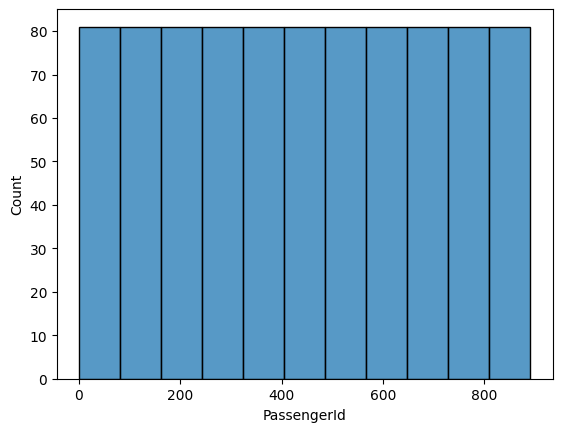

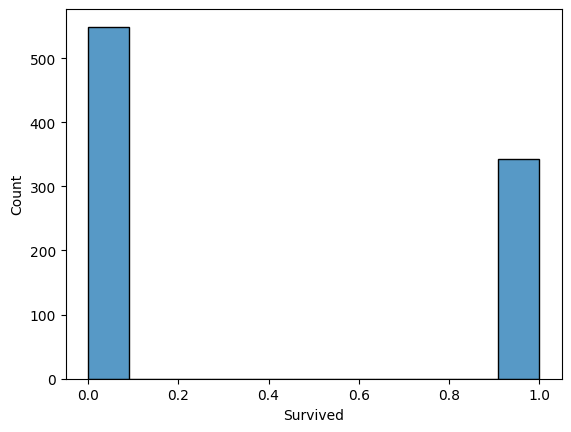

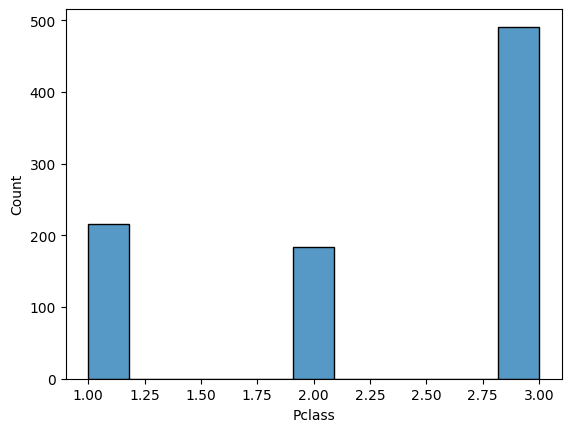

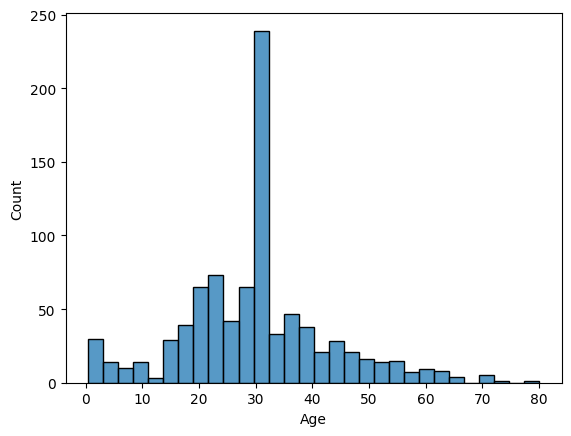

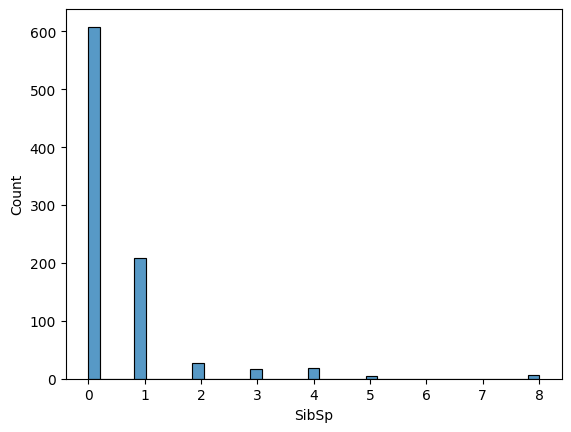

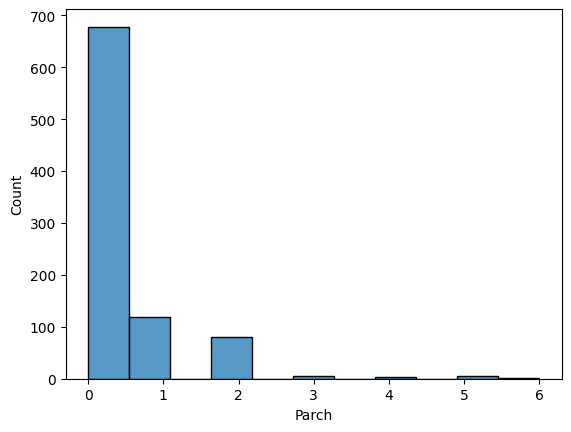

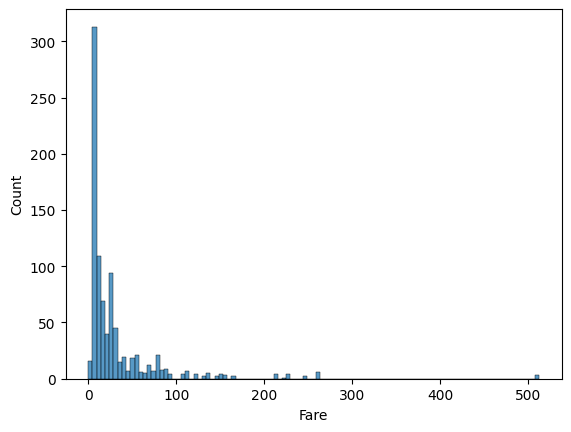

In [ ]:
# for numerical features
for i in num.columns:
  sns.histplot(df[i])
  plt.show()

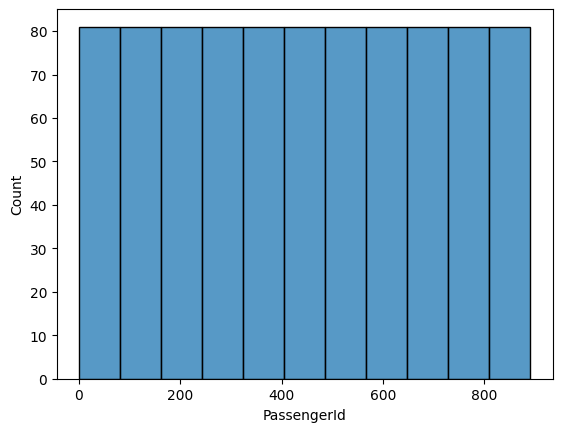

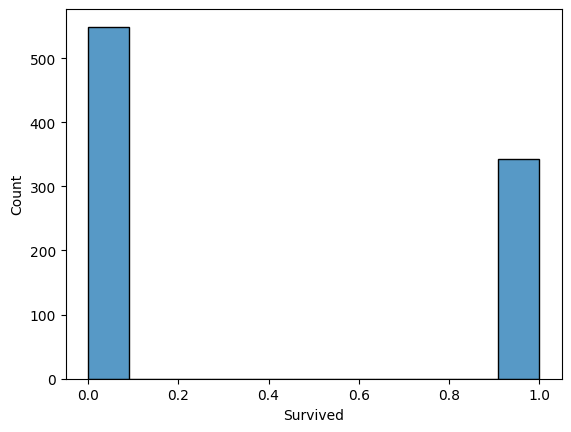

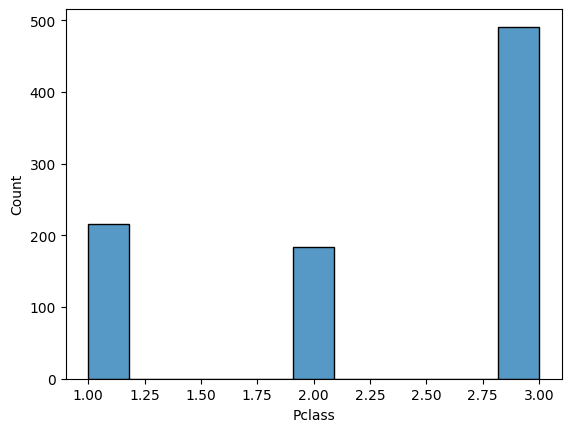

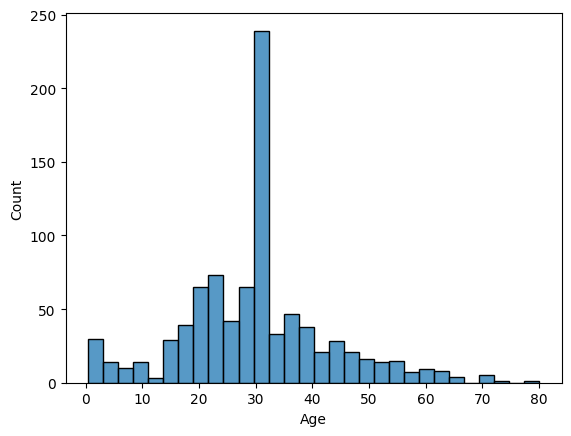

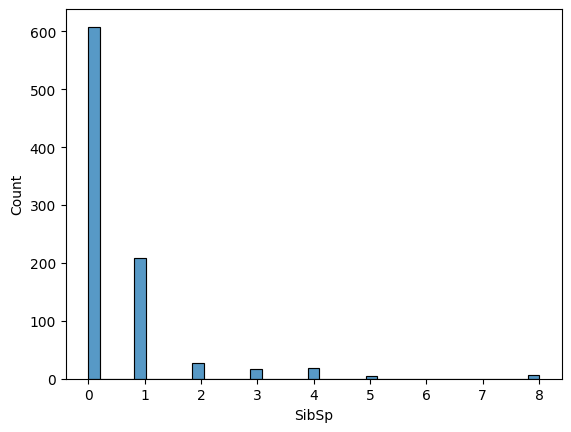

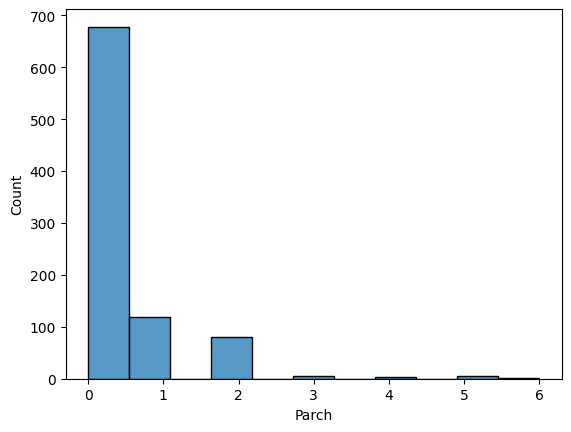

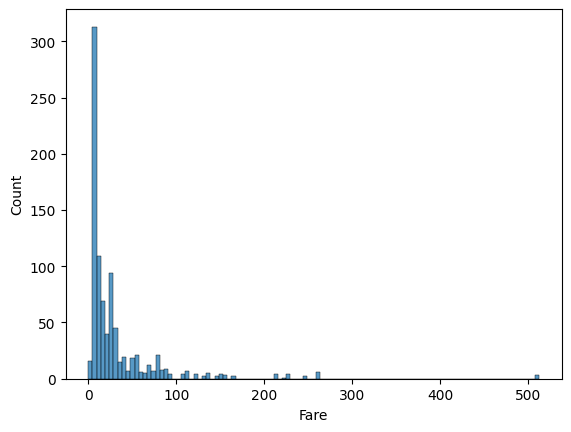

In [ ]:
for i in num.columns:
  sns.histplot(df[i])
  plt.show()

#bivariate analysis

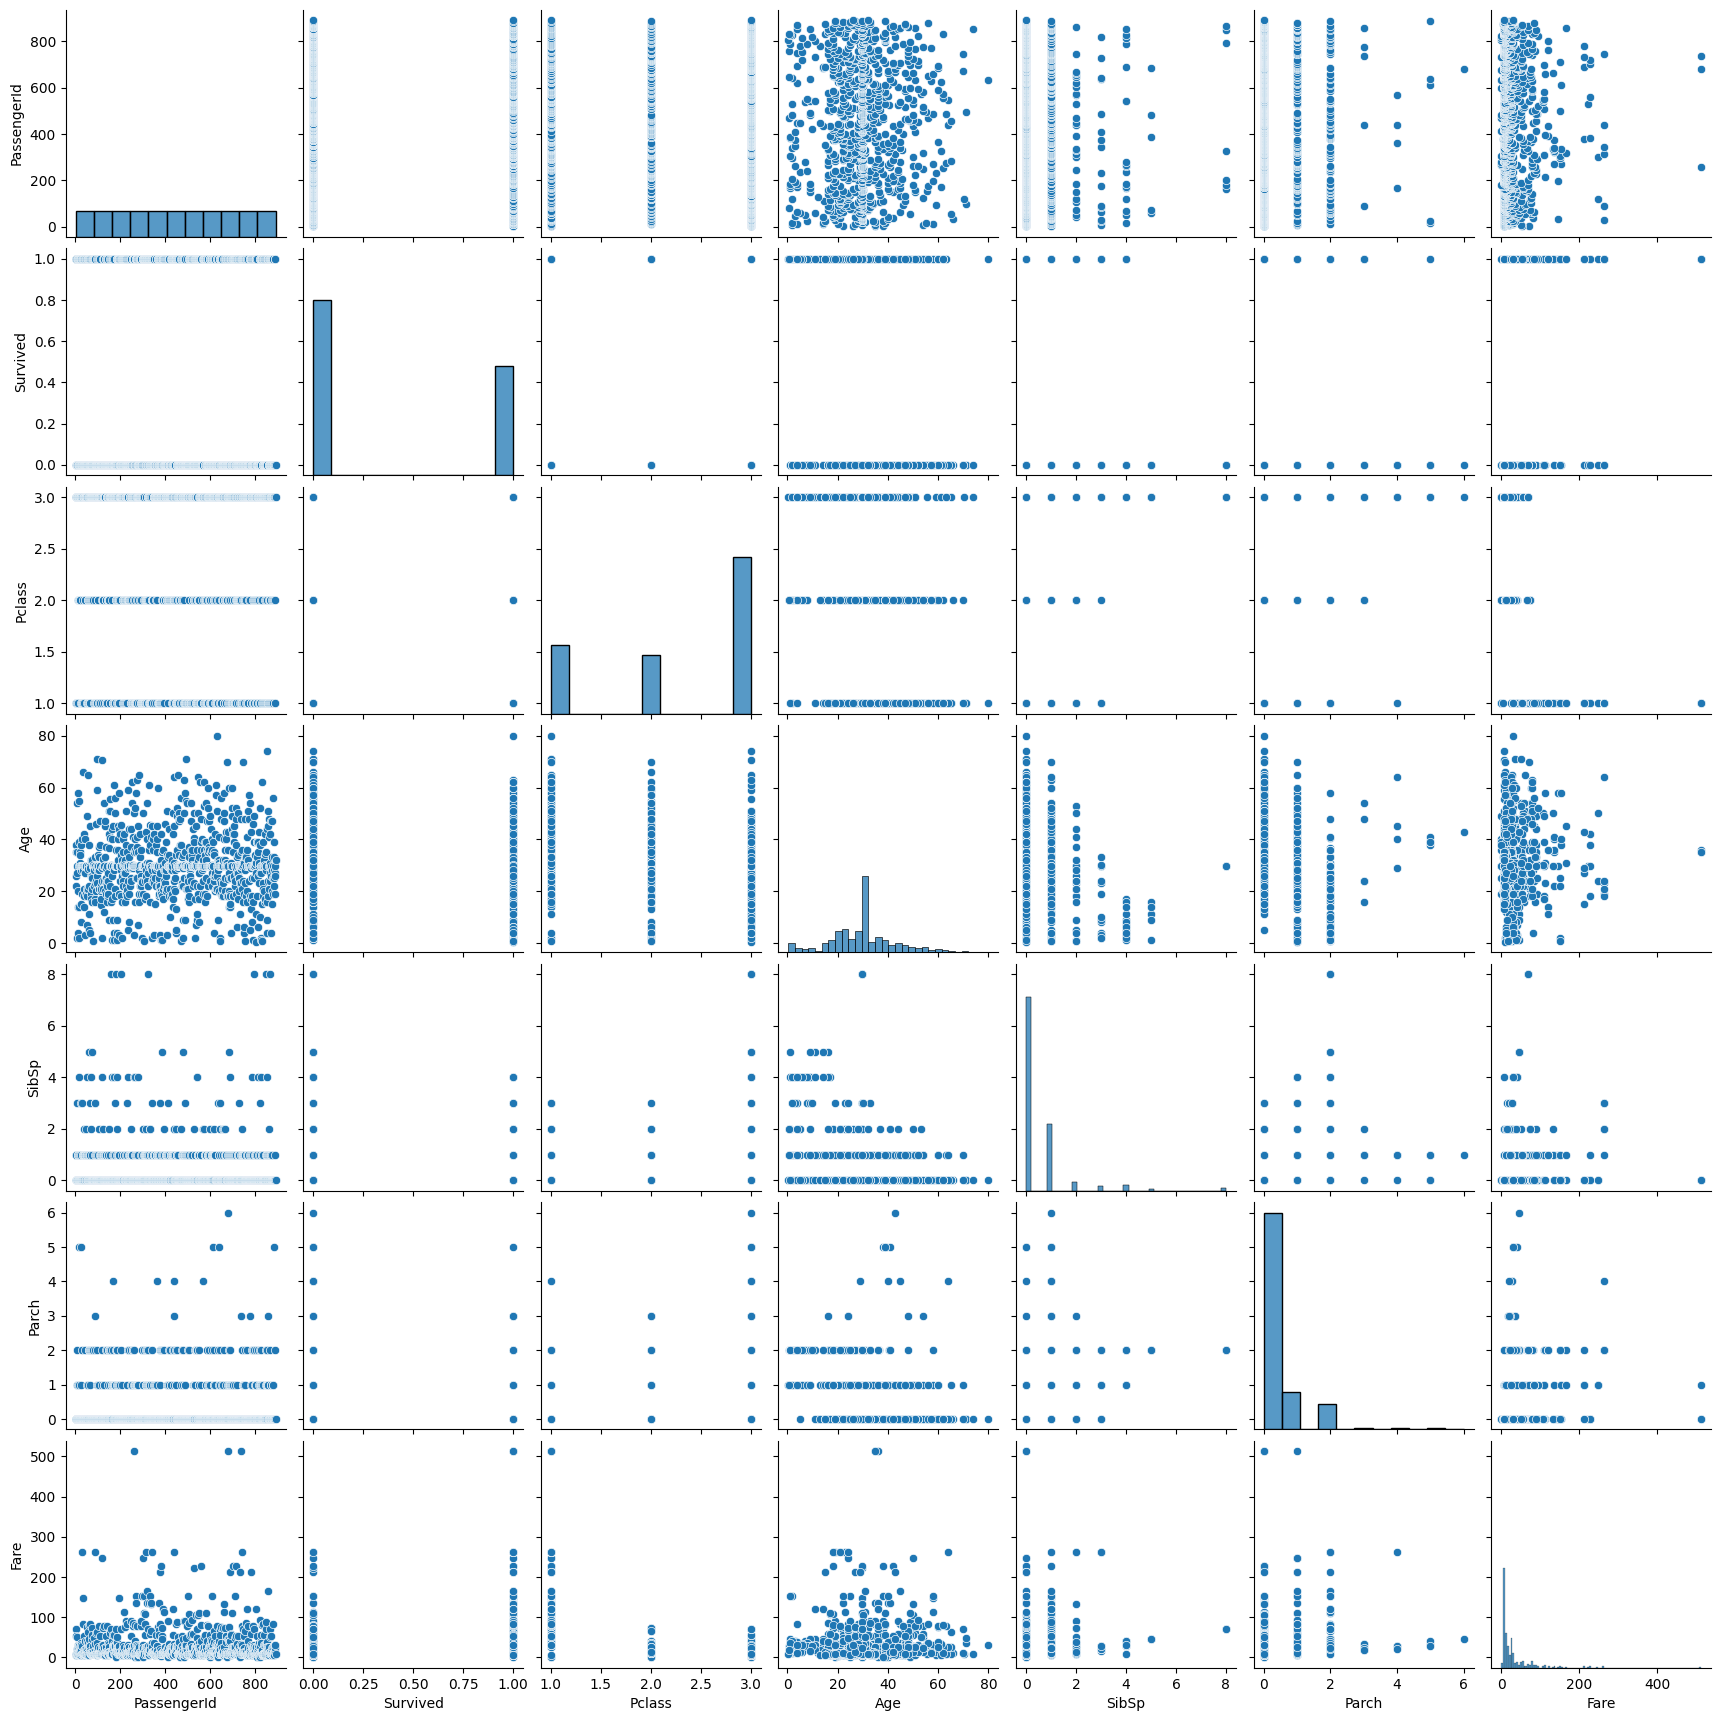

In [ ]:
sns.pairplot(df)
plt.show()

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,Cabin_mode,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,Cabin_mode,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,Cabin_mode,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,Cabin_mode,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,Cabin_mode,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


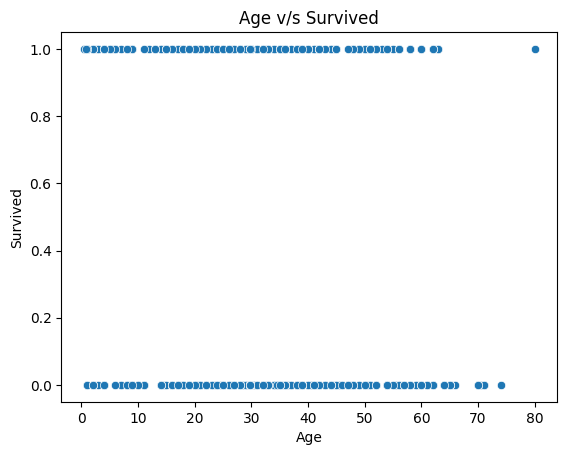

In [ ]:
#bivariate
sns.scatterplot(data=df,x='Age',y='Survived')
plt.title("Age v/s Survived")
plt.show()

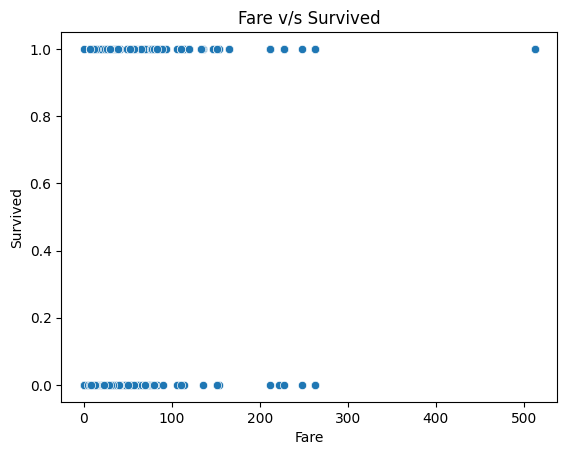

In [ ]:
sns.scatterplot(data=df,x='Fare',y='Survived')
plt.title("Fare v/s Survived")
plt.show()

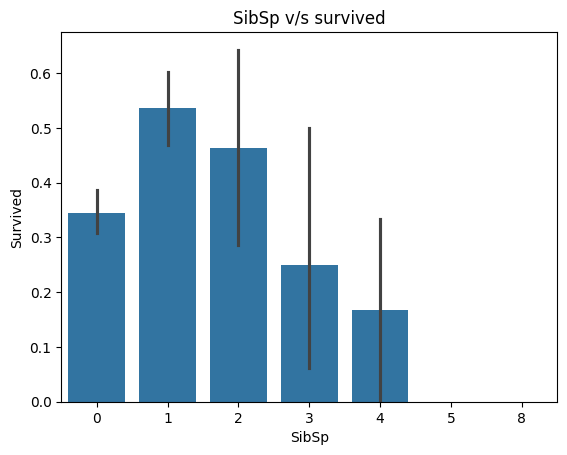

In [ ]:
sns.barplot(data=df,x='SibSp',y='Survived')
plt.title("SibSp v/s survived")
plt.show()

#multivariate analysis

In [ ]:
#multivariate

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,Cabin_mode,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,Cabin_mode,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,Cabin_mode,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,Cabin_mode,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,Cabin_mode,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


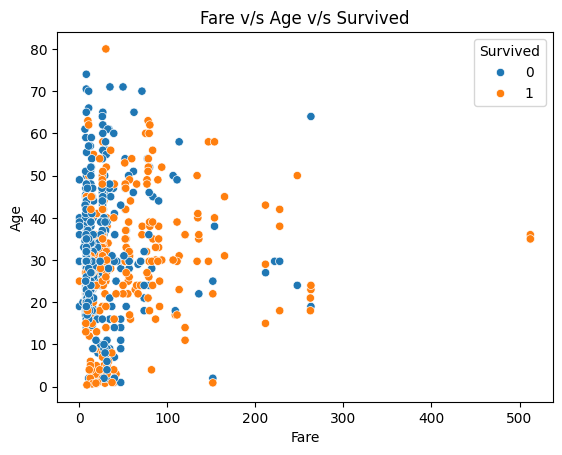

In [ ]:
sns.scatterplot(data=df,x='Fare',y='Age',hue='Survived')
plt.title("Fare v/s Age v/s Survived")
plt.show()

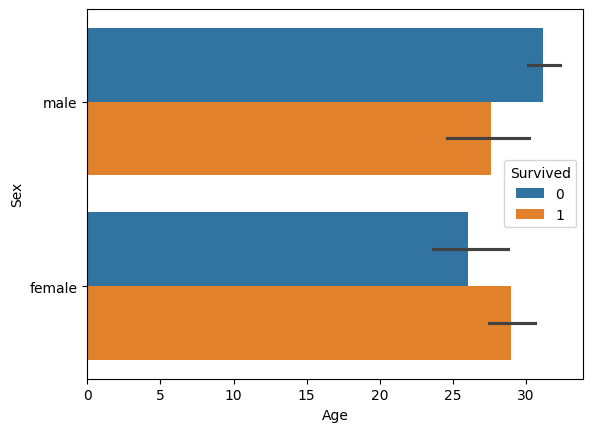

In [ ]:
sns.barplot(data=df,x='Age',y='Sex',hue='Survived')
plt.show()

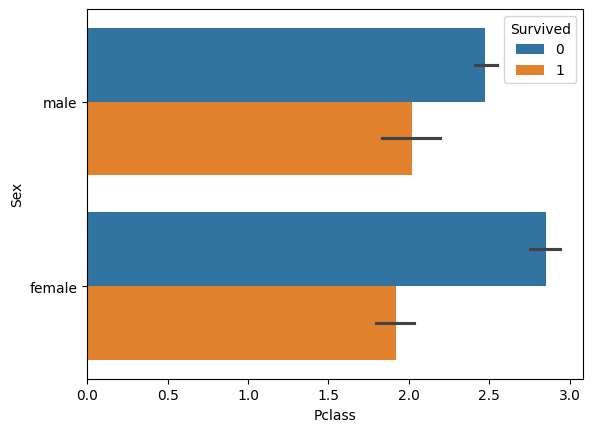

In [ ]:
sns.barplot(data=df,x='Pclass',y='Sex',hue='Survived')
plt.show()

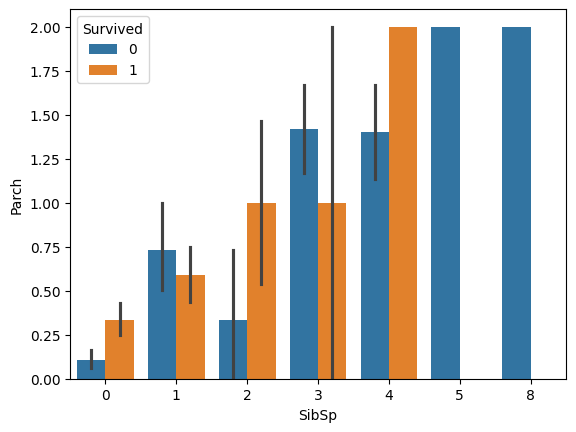

In [ ]:
sns.barplot(data=df,x='SibSp',y='Parch',hue='Survived')
plt.show()

#feature engineering

#Data Encoding
* label encoding
* one hot encoding
*target encoding

#label encoding

In [ ]:
Ib_Sex = LabelEncoder()
df['Sex'] = Ib_Sex.fit_transform(df['Sex'])

# target encoding

In [ ]:
tb_Cabin = TargetEncoder(cols=['Cabin'])
df['Cabin'] = tb_Cabin.fit_transform(df['Cabin'],df['Survived'])

In [ ]:
tb_Name = TargetEncoder(cols=['Name'])
df['Name'] = tb_Name.fit_transform(df[['Name']], df['Survived'])

In [ ]:
tb_Cabin = TargetEncoder(cols=['Cabin'])
df['Cabin'] = tb_Cabin.fit_transform(df[['Cabin']], df['Survived'])

In [ ]:
tb_Embarked = TargetEncoder(cols=['Embarked'])
df['Embarked'] = tb_Embarked.fit_transform(df[['Embarked']], df['Survived'])

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,0.333898,1,22.000000,1,0,A/5 21171,7.2500,0.299854,0.336957
1,2,1,1,0.464006,0,38.000000,1,0,PC 17599,71.2833,0.986518,0.553571
2,3,1,3,0.464006,0,26.000000,0,0,STON/O2. 3101282,7.9250,0.299854,0.336957
3,4,1,1,0.464006,0,35.000000,1,0,113803,53.1000,0.447708,0.336957
4,5,0,3,0.333898,1,35.000000,0,0,373450,8.0500,0.299854,0.336957
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,0.333898,1,27.000000,0,0,211536,13.0000,0.299854,0.336957
887,888,1,1,0.464006,0,19.000000,0,0,112053,30.0000,0.986518,0.336957
888,889,0,3,0.333898,0,29.699118,1,2,W./C. 6607,23.4500,0.299854,0.336957
889,890,1,1,0.464006,1,26.000000,0,0,111369,30.0000,0.986518,0.553571


# Handling outlayers

In [ ]:
q1 =np.quantile(df['Age'],0.25)
q3 =np.quantile(df['Age'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True,inplace=True)
for i in range(len(df)):
   if df.loc[i, 'Age'] > max_bound:
        df.loc[i, 'Age'] = max_bound

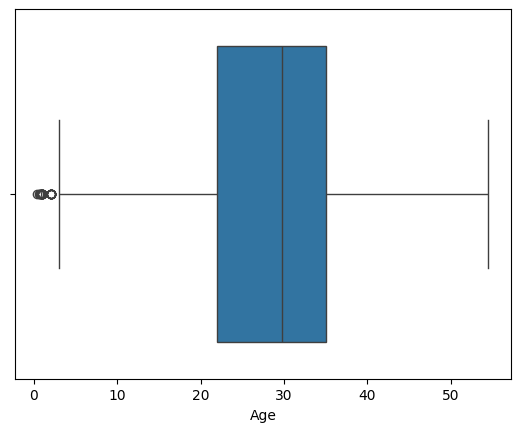

In [ ]:
sns.boxplot(df['Age'],orient='h')
plt.show()

In [ ]:
q1 = np.quantile(df['Fare'],0.25)
q3 = np.quantile(df['Fare'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True, inplace=True)
for i in range(len(df)):
    if df.loc[i, 'Fare'] > max_bound:
        df.loc[i, 'Fare'] = max_bound

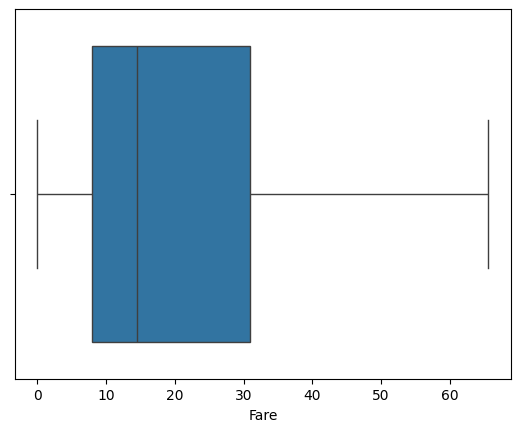

In [ ]:
sns.boxplot(df['Fare'],orient='h')
plt.show()

# checking for corelation

In [ ]:
# Check the data types of the DataFrame columns
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name           float64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin          float64
Embarked       float64
dtype: object


In [ ]:
# Select only numerical columns for correlation calculation
df_numeric = df.select_dtypes(include=np.number)

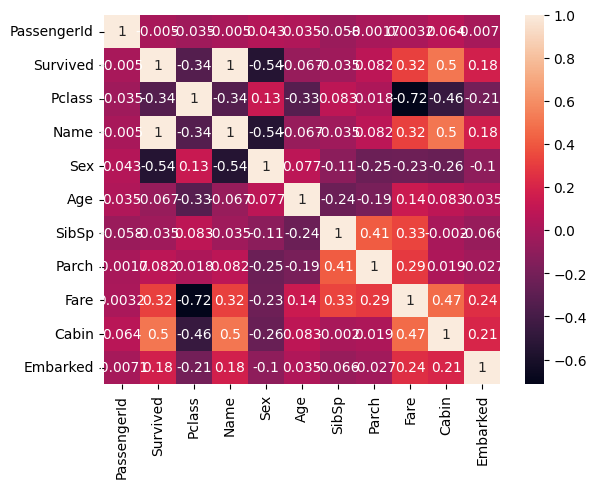

In [ ]:
# Calculate and plot the correlation heatmap using only the numerical columns
sns.heatmap(df_numeric.corr(), annot=True)
plt.show()

In [ ]:
#picking coloumns from highest corelation
df_new = df[['Embarked','Fare','Cabin','Name','Survived']]

# checking for coefficent

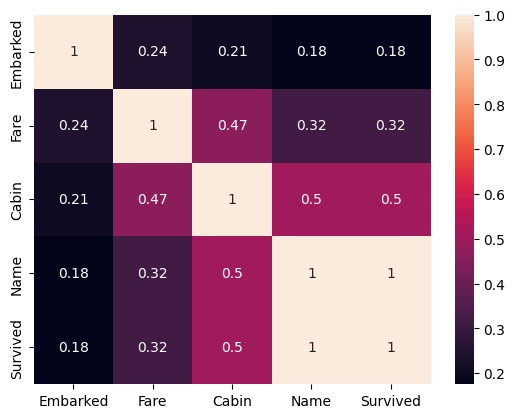

In [ ]:
sns.heatmap(df_new.corr(),annot=True)
plt.show()

In [ ]:
selected = ['Embarked','Fare','Cabin','Name','Survived']

In [ ]:
new=df_new[selected]
new

,Embarked,Fare,Cabin,Name,Survived
0,0.336957,7.2500,0.299854,0.333898,0
1,0.553571,65.6344,0.986518,0.464006,1
2,0.336957,7.9250,0.299854,0.464006,1
3,0.336957,53.1000,0.447708,0.464006,1
4,0.336957,8.0500,0.299854,0.333898,0
...,...,...,...,...,...
886,0.336957,13.0000,0.299854,0.333898,0
887,0.336957,30.0000,0.986518,0.464006,1
888,0.336957,23.4500,0.299854,0.333898,0
889,0.553571,30.0000,0.986518,0.464006,1


# Data scaling

In [ ]:
Embarked_std = StandardScaler()
df_new['Embarked'] = Embarked_std.fit_transform(df_new[['Embarked']])

In [ ]:
Name_std = StandardScaler()
df_new['Name'] = Name_std.fit_transform(df_new[['Name']])

In [ ]:
Fare_std = StandardScaler()
df_new['Fare'] = Fare_std.fit_transform(df_new[['Fare']])

In [ ]:
Cabin_std = StandardScaler()
df_new['Cabin'] = Cabin_std.fit_transform(df_new[['Cabin']])

# model building

In [ ]:
df_new

,Embarked,Fare,Cabin,Name,Survived
0,-0.544614,-0.820552,-0.328330,-0.789272,0
1,2.037198,2.031623,2.643692,1.266990,1
2,-0.544614,-0.787578,-0.328330,1.266990,1
3,-0.544614,1.419297,0.311611,1.266990,1
4,-0.544614,-0.781471,-0.328330,-0.789272,0
...,...,...,...,...,...
886,-0.544614,-0.539655,-0.328330,-0.789272,0
887,-0.544614,0.290823,2.643692,1.266990,1
888,-0.544614,-0.029155,-0.328330,-0.789272,0
889,2.037198,0.290823,2.643692,1.266990,1


In [ ]:
x=df_new.drop('Survived',axis=1)
y=df_new['Survived']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:

# Ensure y_train is of integer type just in case
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [ ]:
x_train

,Embarked,Fare,Cabin,Name
331,-0.544614,0.217546,-0.293469,-0.789272
733,-0.544614,-0.539655,-0.328330,-0.789272
382,-0.544614,-0.787578,-0.328330,-0.789272
704,-0.544614,-0.791036,-0.328330,-0.789272
813,-0.544614,0.353109,-0.328330,-0.789272
...,...,...,...,...
106,-0.544614,-0.801012,-0.328330,1.266990
270,-0.544614,0.339675,-0.328330,-0.789272
860,-0.544614,-0.485513,-0.328330,-0.789272
435,-0.544614,2.031623,0.483156,1.266990


In [ ]:
y_train

,Survived
331,0
733,0
382,0
704,0
813,0
...,...
106,1
270,0
860,0
435,1


In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 4)
(179, 4)
(712,)
(179,)


# knn

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
knn.score(x_train,y_train)

1.0

In [ ]:
knn.score(x_test,y_test)

1.0

In [ ]:
y_pred=knn.predict(x_test)
y_pred

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 1])

In [ ]:
result=pd.DataFrame({'actual':y_test,'predicted':y_pred})
result

,actual,predicted
709,1,1
439,0,0
840,0,0
720,1,1
39,1,1
...,...,...
433,0,0
773,0,0
25,1,1
84,1,1


In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: 1.0
Mean Squared Error: 0.0


# logistic regression

In [ ]:
log=LogisticRegression()
log.fit(x_train,y_train)

LogisticRegression()

In [ ]:
log.score(x_train,y_train)

1.0

In [ ]:
log.score(x_test,y_test)

1.0

In [ ]:
#evaluation
y_pred_log = log.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log,labels=[0,1]))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



In [ ]:
# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Confusion Matrix:
 [[105   0]
 [  0  74]]


# decision tree

In [ ]:
# Create Decision Tree classifer object using entropy
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

In [ ]:
clf = clf.fit(x_train,y_train)

In [ ]:
y_pred_clf = clf.predict(x_test)

In [ ]:
clf.score(x_train,y_train)

1.0

In [ ]:
clf.score(x_test,y_test)

1.0

In [ ]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred_clf))

Accuracy: 1.0


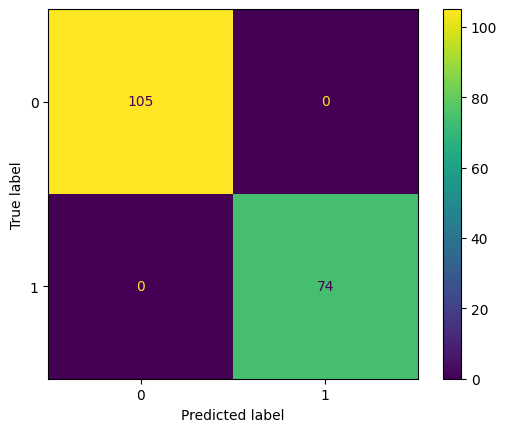

In [ ]:
cm = confusion_matrix(y_test, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# random forest

In [ ]:
iris = load_iris()
x = iris.data
y = iris.target

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf.score(x_train,y_train)

1.0

In [ ]:
rf.score(x_test,y_test)

1.0

In [ ]:
y_pred_rf = rf.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



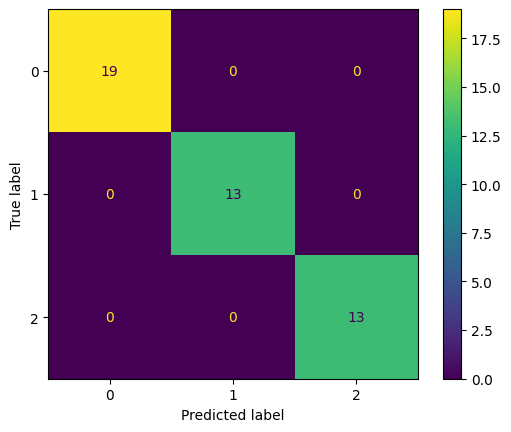

In [ ]:
rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=rf)
disp.plot()

# adaboost

In [ ]:
ab= AdaBoostClassifier(n_estimators=10, random_state=42)
ab.fit(x_train, y_train)

AdaBoostClassifier(n_estimators=10, random_state=42)

In [ ]:
y_pred_ab = ab.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_ab))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ab))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



#support vector classification

In [ ]:
sv = SVC()
sv.fit(x_train, y_train)

SVC()

In [ ]:
y_pred_sv = sv.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_sv))
print("\nClassification Report:\n", classification_report(y_test, y_pred_sv))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



#naive bayes classification

In [ ]:
nb = GaussianNB()
nb.fit(x_train,y_train)

GaussianNB()

In [ ]:
y_pred_nb =nb.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Accuracy: 0.9777777777777777

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



# model comparison graph

In [ ]:
# Initialize models
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

In [ ]:
# Train, predict and collect accuracy
accuracy_scores = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy_scores[name] = accuracy_score(y_test, y_pred)

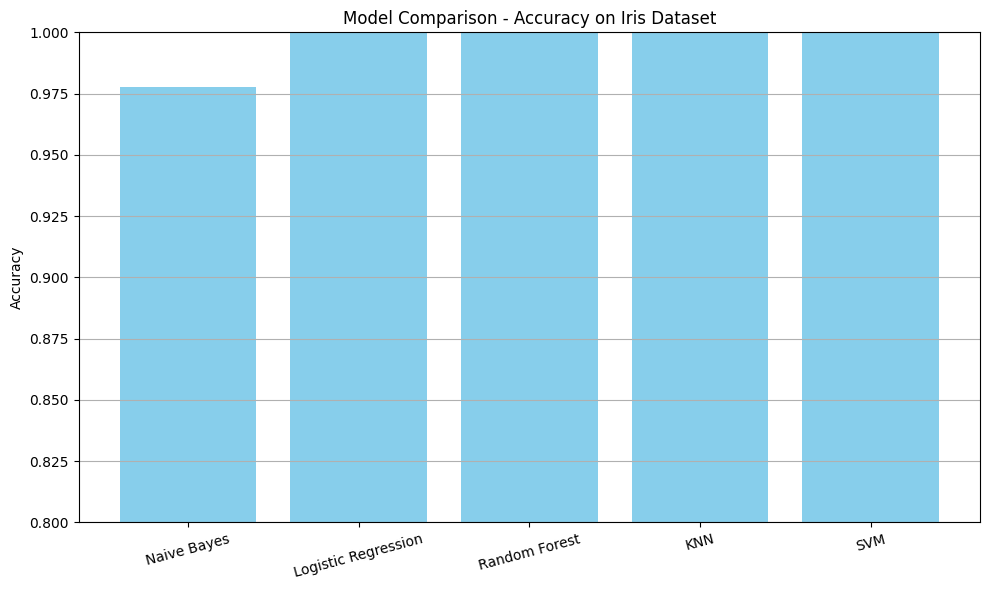

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color='skyblue')
plt.title('Model Comparison - Accuracy on Iris Dataset')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.grid(axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# Initialize models
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}
# Score storage
results = []

In [ ]:
# Loop through models
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

In [ ]:
# Create DataFrame
df_results = pd.DataFrame(results)
print(df_results)

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.977778    0.97619  0.974359  0.974321
1  Logistic Regression  1.000000    1.00000  1.000000  1.000000
2        Random Forest  1.000000    1.00000  1.000000  1.000000
3                  KNN  1.000000    1.00000  1.000000  1.000000
4                  SVM  1.000000    1.00000  1.000000  1.000000
